# Aflevering 3

## Exercise 7 - Stats in Python

### 1a. Load data

In [ ]:
from sklearn.datasets import load_breast_cancer
import pandas as pd
import numpy as np
cancer = load_breast_cancer()
df = pd.DataFrame(cancer.data, columns=cancer.feature_names)

Data skulle indeholde følgende: 569 clinical samples and 30 tumor-related features.

In [ ]:
np.shape(df)

(569, 30)

Vi vælger 'mean area' som vores kontinuere biomedicinske variabel.

In [ ]:
data = df['mean area']

### 1b. Plot histogram and QQ-plot.

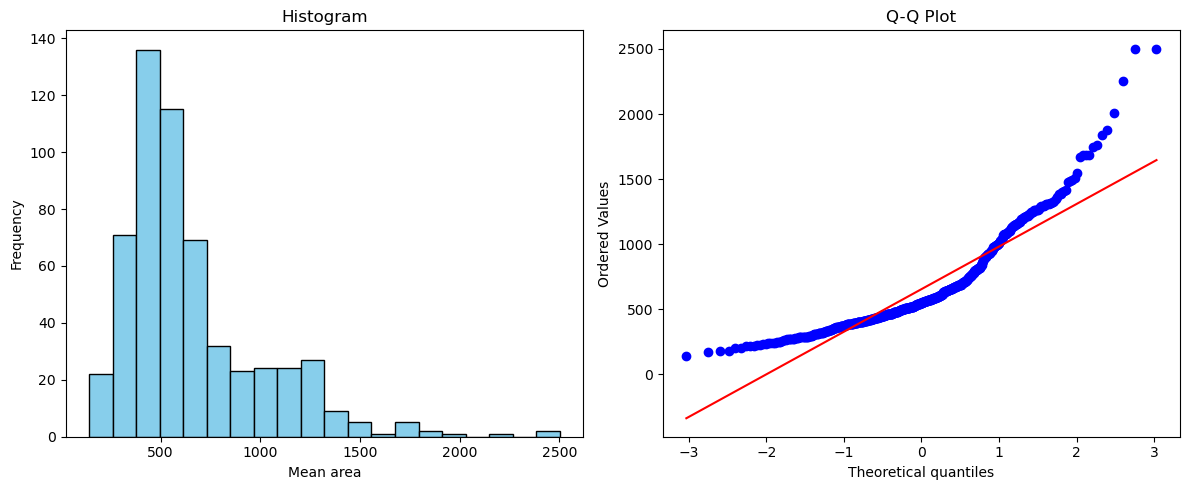

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# Create distribution + QQ plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Histogram
axes[0].hist(data, bins=20, color='skyblue', edgecolor='black')
axes[0].set_title('Histogram')
axes[0].set_xlabel('Mean area')
axes[0].set_ylabel('Frequency')

# QQ Plot with scipy (normal reference)
stats.probplot(data, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot')

plt.tight_layout()

Fra både histogram og Q-Q plot ser det ikke ud som at data er normalfordelte.

### 1c. Test for normality using Shapiro-Wilk.

In [ ]:
shapiro_result = stats.shapiro(data).pvalue
print(f'Shapiro-Wilk:{shapiro_result}')

Shapiro-Wilk:3.1962641979601284e-22


Med en p-værdi under 0.05 i testen afvises nul-hypotesen om at data er normalfordelte.

### 1d. Apply a log transformation

Vi log transformerer data for at se om dette kan gøre data normalfordelte.

In [ ]:
log_data = np.log(data)

### 1e. Plot histogram & Q–Q plot (after transform)

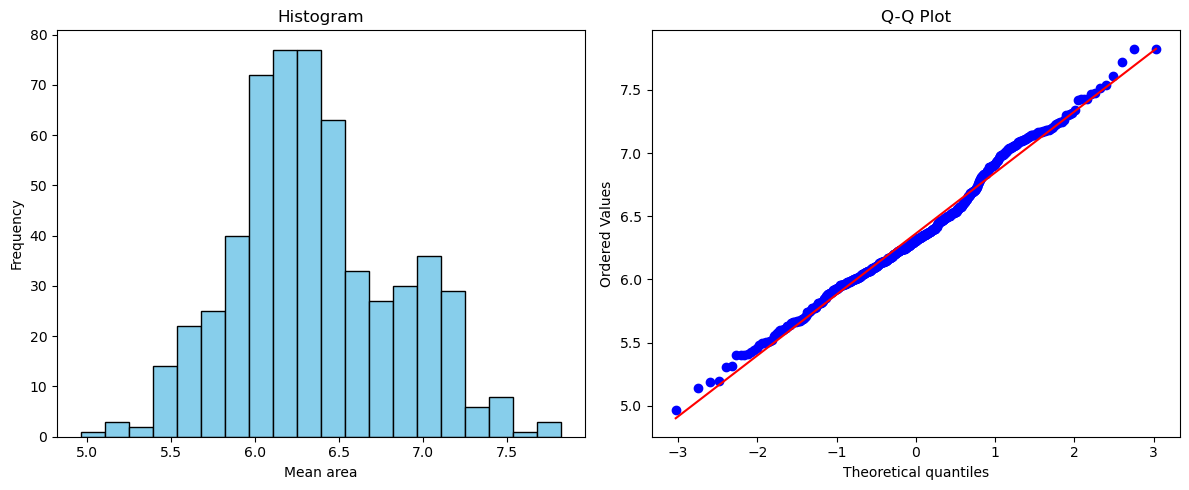

In [ ]:
# Create distribution + QQ plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Histogram
axes[0].hist(log_data, bins=20, color='skyblue', edgecolor='black')
axes[0].set_title('Histogram')
axes[0].set_xlabel('Mean area')
axes[0].set_ylabel('Frequency')

# QQ Plot with scipy (normal reference)
stats.probplot(log_data, dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot')

plt.tight_layout()

Fra histogram og Q-Q plot ser de log transformerede data nu normalfordelte ud.

### 1f. Re-test normality after log transformation

In [ ]:
shapiro_result = stats.shapiro(log_data).pvalue
print('Shapiro-Wilk:', shapiro_result)

Shapiro-Wilk: 0.0001091582588219218


Shapiro-Wilk test kan dog stadig ikke bekræfte nul-hypotesen om at data er normalfordelte.

## Exercise 2. 
One-Way ANOVA on Serum Cholesterol Across Chest Pain Types

### 2a. Load the real biomedical dataset
"heart_disease" fra seaborn eksisterer ikke. Istedet har vi fundet et forhåbentligt lignende dataset fra sklearn.datasets.

Vi kigger specifikt på kolesterol (chol) og brystsmerte (cp) værdier.

In [ ]:
from sklearn.datasets import fetch_openml
import pandas as pd

heart = fetch_openml(name="heart-disease", version=1, as_frame=True)
df = heart.frame.copy()

df["chol"] = pd.to_numeric(df["chol"])
df["cp"] = pd.to_numeric(df["cp"])

describe() giver et overblik over fordelingen af værdier for f.eks. cp og chol i datasættet.

In [ ]:
df[['cp', 'chol']].describe()

,cp,chol
count,303.000000,303.000000
mean,0.966997,246.264026
std,1.032052,51.830751
min,0.000000,126.000000
25%,0.000000,211.000000
50%,1.000000,240.000000
75%,2.000000,274.500000
max,3.000000,564.000000


Med value_counts() kan vi se hvor mange gange forskellige cp værdier er givet til patienterne.

In [ ]:
df['cp'].value_counts()

cp
0.0    143
2.0     87
1.0     50
3.0     23
Name: count, dtype: int64

### 2b. Split cholesterol values by chest-pain group 1-4.
Her kan vi bruge Pythons comprehension til at lave en dictionary over grupperne.

In [ ]:
chol_cp_groups = {i: df.loc[df["cp"] == i,"chol"] for i in [1, 2, 3, 4]}

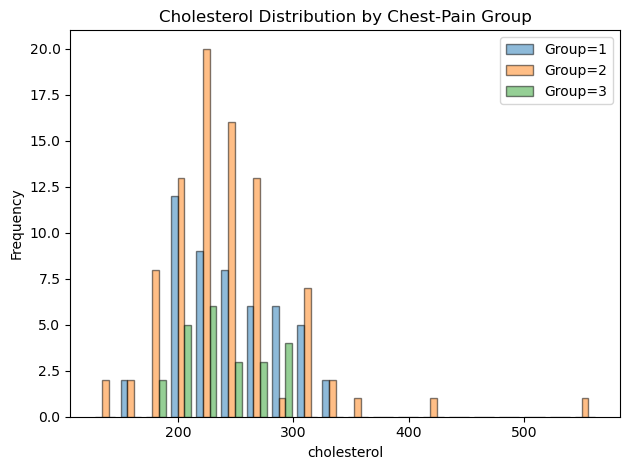

In [ ]:
import matplotlib.pyplot as plt

plot_groups = {
    i: df.loc[df["cp"] == i, "chol"].dropna().to_numpy()
    for i in [1, 2, 3, 4]
}
plot_groups = {k: v for k, v in plot_groups.items() if len(v) > 0}

# Prepare data
data = list(plot_groups.values())
labels = [f"Group={k}" for k in plot_groups.keys()]

# Single combined histogram
plt.hist(data, bins=20, alpha=0.5, edgecolor="black", label=labels)

plt.title("Cholesterol Distribution by Chest-Pain Group")
plt.xlabel("cholesterol")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

### 2c. Check ANOVA assumptions (normality and equal variances).

Test af normalitet med Shapiro-Wilk.

In [ ]:
from scipy.stats import ttest_ind
from scipy.stats import shapiro

for group, data in chol_cp_groups.items():
    # Test normality with Shapiro-Wilk
    if len(data) >= 3:
        stat, p = shapiro(data)
        if p > 0.05:
            print(f"Group {group} follows a normal distribution. p={p:.2}")
        else:
            print(f"Group {group} DOES NOT follow a normal distribution. p={p:.2}")
    else: print(f"Sample size to small for Group {group}")

Group 1 follows a normal distribution. p=0.34
Group 2 DOES NOT follow a normal distribution. p=2.3e-07
Group 3 follows a normal distribution. p=0.41
Sample size to small for Group 4


Test af ens varians med levene.

In [ ]:
from scipy.stats import levene
for group_A in range(1,5):
    for group_B in range(group_A+1,5):
        data_A = chol_cp_groups[group_A]
        data_B = chol_cp_groups[group_B]
        if len(data_A) & len(data_B):
            stat, p = levene(data_A, data_B)
            if p > 0.05:
                print(f"Groups {group_A} and {group_B} have equal variances. p={p:.2}")
            else:
                print(f"Groups {group_A} and {group_B} DOES NOT have equal variances. p={p:.2}")

Groups 1 and 2 have equal variances. p=0.43
Groups 1 and 3 have equal variances. p=0.16
Groups 2 and 3 have equal variances. p=0.15


### 2d. Run One-Way ANOVA

In [ ]:
from scipy.stats import f_oneway
f_stat, p_value = f_oneway(chol_cp_groups[1], chol_cp_groups[2], chol_cp_groups[3])
print("F =", f_stat)
print("p =", p_value)

F = 0.1733209417714393
p = 0.8410283712705904


Da p > 0.05 kan vi ikke forkaste nul-hypotesen om at middelværdierne er ens for de 3 grupper.

### 2e. If significant, run Tukey HSD (Honestly Significant Difference)

Da vi ikke så en forskel i ANOVA testen. Giver Tukey ikke mening.

### 2f. Visualize the results using boxplots.

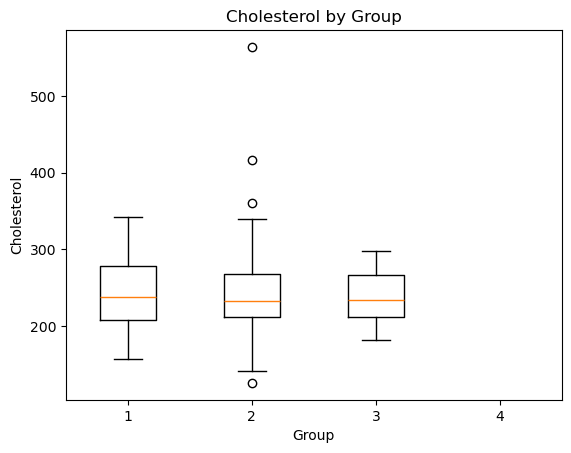

In [ ]:
plt.boxplot(chol_cp_groups.values(), tick_labels=chol_cp_groups.keys())

plt.ylabel("Cholesterol")
plt.xlabel("Group")
plt.title("Cholesterol by Group")
plt.show()

Fra boxplot ligner det heller ikke at der er nogen forskel imellem grupperne.

## Exercise 8 - Secure Data Processing

In [ ]:
import os
from cryptography.hazmat.primitives import hashes, serialization
from cryptography.hazmat.primitives.asymmetric import rsa, padding
from cryptography.hazmat.primitives.ciphers import Cipher, algorithms, modes
from cryptography.hazmat.primitives.padding import PKCS7
from cryptography.hazmat.backends import default_backend

### 1. Symmetric Layer (AES-CBC) for large files.

Vi implementerer funktioner til symmetrisk kryptering og afkryptering af data.

AES = Advanced Encryption Standard

Cipher Block Chaining (CBC)

AES opererer i blokke af bestemte størrelser. Derfor benyttes PKCS7 til padding.

In [ ]:
def encrypt_data(data, aes_key):
    iv = os.urandom(16)

    padder = PKCS7(128).padder()
    padded_data = padder.update(data) + padder.finalize()

    cipher = Cipher(
        algorithms.AES(aes_key),
        modes.CBC(iv),
        backend=default_backend()
    )
    encryptor = cipher.encryptor()
    ciphertext = encryptor.update(padded_data) + encryptor.finalize()

    return iv, ciphertext

def decrypt_data(iv, ciphertext, aes_key):
    cipher = Cipher(
        algorithms.AES(aes_key),
        modes.CBC(iv),
        backend=default_backend()
    )
    decryptor = cipher.decryptor()
    padded_data = decryptor.update(ciphertext) + decryptor.finalize()

    unpadder = PKCS7(128).unpadder()
    data = unpadder.update(padded_data) + unpadder.finalize()

    return data

Vi kan prøve at kryptere og afkryptere en data pakke.

In [ ]:
aes_key = os.urandom(32)
raw_data = b"HowAreYouDoing?"
iv, ciphertext = encrypt_data(raw_data, aes_key)
print(f"Before encryption: {raw_data}")
print(f"After encryption: iv={iv} ciphertext={ciphertext}")

decrypt_data = decrypt_data(iv, ciphertext, aes_key)
print(f"After decryption: {decrypt_data}")

Before encryption: b'HowAreYouDoing?'
After encryption: iv=b'%\n\xbb\xd7\x7f\xdf\x98Y3u\x1br\xed\x01Q*' ciphertext=b'\xe6,f\xae\x9a\xdd\xb3\xe6.\xbbqv-\x0e+"'
After decryption: b'HowAreYouDoing?'


### 2. Assymetric layer (RSA-OAEP)

Vi implementerer funktioner til asymmetrisk kryptering og afkryptering af data.

RSA = Rivest–Shamir–Adleman

OAEP = Optimal Asymmetric Encryption Padding

Her benyttes en Public og Private nøgle til at beskytte AES nøglen, så kun brugeren med private nøgle kan benytte den.

#### 2.1 Generate RSA Keys

In [ ]:
def generate_rsa_keys():
    private_key = rsa.generate_private_key(
        public_exponent=65537,
        key_size=2048
    )
    public_key = private_key.public_key()
    return private_key, public_key

De generede nøgler er objekter.

In [ ]:
pub_key, pri_key = generate_rsa_keys()
print(pub_key)
print(pri_key)

#### 2.2 Wrap using RSA-OAEP

Vi implementerer metoder til at wrappe og unwrappe AES nøglen.

In [ ]:
def wrap_key(aes_key, public_key):
    encrypted_key = public_key.encrypt(
        aes_key,
        padding.OAEP(
            mgf=padding.MGF1(algorithm=hashes.SHA256()),
            algorithm=hashes.SHA256(),
            label=None
        )
    )
    return encrypted_key


def unwrap_key(encrypted_key, private_key):
    aes_key = private_key.decrypt(
        encrypted_key,
        padding.OAEP(
            mgf=padding.MGF1(algorithm=hashes.SHA256()),
            algorithm=hashes.SHA256(),
            label=None
        )
    )
    return aes_key

Vi prøver at wrappe og unwrappe en AES nøgle med metoderne.

In [ ]:
aes_key = os.urandom(32)
private, public = generate_rsa_keys()

encrypted_key = wrap_key(aes_key,public)
decrypted_key = unwrap_key(encrypted_key,private)

print(f"Initial AES key\n{aes_key}\n\nEncrypted key\n{encrypted_key}\n\nDecrypted key\n{decrypted_key}")

Initial AES key
b'+\xe8\x89ANCA,t\xf4U\x05$v\xf9\xd3\x8aw\xfd\x90\xfa\xeat\xa9\x01\xbe,\xc0\xbbO\x04\xeb'

Encrypted key
b'kt_\x90\x12\xfbY\xe7\x9fc\xa0\xb6\xce\xc5\\\x9d)\x8a\xbe\xc5t6\xc2\xf9%\xf8\xbd\xcb\xa9\x95\xd1\xee\x12\x04\xc2EE\x81\x06\xfb\xa8\xe2\xb9\x05\x86\xd3*{Uu\x0f\xee}\xe8\xf8\xd6i\xdc\xc8<\xe1G\xbeXcu\x1bY\xbb\xd3v)\x01\x9f0\x9b\xc9\xa1\xc8Z\xd0#\xd4\x1a\xb9B\\M\x16[\xe7\n\xb1\x8ah6\xa8\x00\x1a\xba\x01\xf2\x10\xb5u\xff\xec\x9aD<q?\xd1i\x1d\x02#\x83\x0c\x88-\xfc\xf7\xe6\x8d\xce\x1bNi\xb7%\xea\xcb\xa5\xd0\xbc\x9f\rXE\x14\x8a\xe0Ik\xf4\xb6\xef\xde\xbfE\x82?\xba\x81&\x81\xbfHM\x1cJ\xa2\xfb\xe8\xbb\x8c\xc0\x07\xb9\xda\xf5\xbc\xa8\x1fq\xc8\xe73\x02f\xad\xaa\xe1+\xb3t\x0f\x8d\xc5\x01\x95\xa4\x1d\x97_\xe2U\xb5\xdd:c\x88\x89"S+\xbc<\xed\xf6\xe5,\xf6\x11\xf6\xc8\xd7\xc9M7{FLR\x156y\x0e_\xa9\xefq\x93\n\xf5N\xc6"BJb\x97\x1f\x1a\xb2\xf5\x03j\xda,Y\xb1s.\xf9'

Decrypted key
b'+\xe8\x89ANCA,t\xf4U\x05$v\xf9\xd3\x8aw\xfd\x90\xfa\xeat\xa9\x01\xbe,\xc0\xbbO\x04\xeb'


### 4. Integrity layer (RSA-PSS).

PSS (Probabilistic Signature Scheme) bruges til at sikre Integrity (data er uændret) og Authenticity (data kommer fra troværdig bruger).
Man siger at den krypterede pakke "signeres digitale".

Hvis data ændres eller bruger ikke er troværdig (ikke har private nøgle) returneres "False".

In [ ]:
def sign_package(private_key, data):
    signature = private_key.sign(
        data,
        padding.PSS(
            mgf=padding.MGF1(hashes.SHA256()),
            salt_length=padding.PSS.MAX_LENGTH
        ),
        hashes.SHA256()
    )
    return signature


def verify_signature(public_key, data, signature):
    try:
        public_key.verify(
            signature,
            data,
            padding.PSS(
                mgf=padding.MGF1(hashes.SHA256()),
                salt_length=padding.PSS.MAX_LENGTH
            ),
            hashes.SHA256()
        )
        return True
    except:
        return False

Vi tester hvad der sker, hvis data ikke er uændret.

In [ ]:
aes_key = os.urandom(32)
raw_data = b"minMegetStaerkeKode"
corrputed_data = b"minMeget_StaerkeKode"

signature = sign_package(private, raw_data)

verification_no_errors = verify_signature(public, raw_data, signature)
print(verification_no_errors)
verification_corrupted_data = verify_signature(public, raw_data, corrputed_data)
print(verification_corrupted_data)

True
False


### 5. Data Vault Process

Vi samler alle delene af vores Vault i to funktioner.

create_vault() - Krypterer data, wrapper AES nøgle og signerer med PSS.

open_vault() - Verificerer data og bruger, unwrapper AES nøgle og afkrypterer data.

In [ ]:
def create_vault(data, public_key, signing_private_key):
    aes_key = os.urandom(32)

    iv, ciphertext = encrypt_data(data, aes_key)

    wrapped_key = wrap_key(aes_key, public_key)

    package = wrapped_key + iv + ciphertext

    signature = sign_package(signing_private_key, package)

    return wrapped_key, iv, ciphertext, signature


def open_vault(wrapped_key, iv, ciphertext, signature, private_key, verify_public_key):
    package = wrapped_key + iv + ciphertext

    if not verify_signature(verify_public_key, package, signature):
        raise Exception("❌ Integrity check failed! Data corrupted or tampered.")

    print("✅ Signature verified.")

    aes_key = unwrap_key(wrapped_key, private_key)

    data = decrypt_data(iv, ciphertext, aes_key)

    return data

### Example

Vi tester at vores Vault kan kryptere og afkryptere data.

In [ ]:
# Simulated biomedical data (ECG)
biomedical_data = "minMegetStaerkeKode".encode("utf-8")

# Generate keys
receiver_private, receiver_public = generate_rsa_keys()
signer_private, signer_public = generate_rsa_keys()

# Create vault
wrapped_key, iv, ciphertext, signature = create_vault(
biomedical_data,
receiver_public,
signer_private
)

print("🔒 Data stored securely.")

# Open vault
decrypted_data = open_vault(
    wrapped_key,
    iv,
    ciphertext,
    signature,
    receiver_private,
    signer_public
)

print("🔓 Decrypted Data:", decrypted_data)

🔒 Data stored securely.
✅ Signature verified.
🔓 Decrypted Data: b'minMegetStaerkeKode'


## Exercise 9 - Optimering

### Del 1

Apparent diffusion coefficient (ADC) kan estimeres fra en eksponential kurve.

$$
S(b) = S_0e^{-b \cdot ADC}
$$
$$
ln(S(b)) = ln(S_0)-b \cdot ADC
$$

Hvor:

S(b) = målt MRI signal ved diffusions vægten b

S0 = signal når b = 0

#### 1a) Artificial data generation

Vi definerer et billede med tre firkanter med forskellige ADC værdier.

Ud fra denne generer vi lignende data, men tilføjer noget støj.

In [ ]:
import numpy as np
import time

nx, ny = 64, 64
ADC_true = np.zeros((nx, ny))
ADC_true[10:30, 10:30] = 0.0007
ADC_true[35:55, 10:30] = 0.0010
ADC_true[20:45, 35:55] = 0.0015
S0 = 1000
bvals = np.array([0, 500, 1000, 1500])

def rician(signal, sigma=20):
    n1 = np.random.normal(0, sigma, signal.shape)
    n2 = np.random.normal(0, sigma, signal.shape)
    return np.sqrt((signal+n1)**2 + n2**2)

data = np.stack([rician(S0*np.exp(-b*ADC_true)) for b in bvals], axis=-1)

#### 1b) Estimate ADC from various methods

Vi estimerer ADC ud fra Log Least Squares, Levenberg-Marquardt og BFGS.

##### Log Least Squares (log-LS)

In [ ]:
ADC_LS = np.zeros_like(ADC_true)
S0_LS = np.zeros_like(ADC_true)

mask = ADC_true > 0
x = bvals

t0 = time.time()

for ix in range(nx):
    for iy in range(ny):
        if not mask[ix, iy]:
            continue

        s = data[ix, iy, :]
        if np.any(s <= 0):
            continue
        y = np.log(s)
        A = np.column_stack([np.ones_like(x), x])
        coeffs, _, _, _ = np.linalg.lstsq(A, y, rcond=None)
        a, b = coeffs  # a = slope and b = intersect
        if b >= 0:
            continue

        ADC_LS[ix, iy] = -1.0 * b
        S0_LS[ix, iy] = np.exp(a)

t_LS = time.time() - t0
print(f"Linear LS time: {t_LS:.3f} s")


Linear LS time: 0.046 s


##### Levenberg-Marquardt (LM)


In [ ]:
from scipy.optimize import curve_fit # Bruger LM metode som default

def adc_model(b, S0, ADC):
    return S0 * np.exp(-b * ADC)

ADC_LM = np.zeros_like(ADC_true)
S0_LM = np.zeros_like(ADC_true)

t0 = time.time()

for ix in range(nx):
    for iy in range(ny):
        if not mask[ix, iy]:
            continue

        s = data[ix, iy, :]
        if np.any(s <= 0):
            continue

        S0_init = S0_LS[ix, iy] if S0_LS[ix, iy] > 0 else 1000
        ADC_init = ADC_LS[ix, iy] if ADC_LS[ix, iy] > 0 else 0.080

        try:
            popt, _ = curve_fit(
                adc_model, bvals, s,
                p0=[1000, 0.001],
                #p0=[S0_init, ADC_init],
                maxfev=2000
            )
            S0_LM[ix, iy], ADC_LM[ix, iy] = popt
        except RuntimeError:
            ADC_LM[ix, iy] = 0

t_LM = time.time() - t0
print(f"LM time: {t_LM:.3f} s")


LM time: 0.208 s


##### BFGS

In [ ]:
from scipy.optimize import minimize
import time

def adc_objective(params, b, signal):
    S0, adc = params
    if S0 <= 0 or adc <= 0:
        return 1e12  # penalize invalid values
    pred = S0 * np.exp(-b * adc)
    return np.sum((signal - pred)**2)


ADC_BFGS = np.zeros_like(ADC_true)
S0_BFGS = np.zeros_like(ADC_true)

t0 = time.time()

for ix in range(nx):
    for iy in range(ny):
        if not mask[ix, iy]:
            continue

        s = data[ix, iy, :]
        if np.any(s <= 0):
            continue

        # Initial guess from LS
        S0_init = S0_LS[ix, iy] if S0_LS[ix, iy] > 0 else 1000
        BFGS_init = ADC_LS[ix, iy] if ADC_LS[ix, iy] > 0 else 0.001

        res = minimize(
            adc_objective,
            #x0=[S0_init, BFGS_init],
            x0=[1000, 0.001],
            args=(bvals, s),
            method="BFGS",
            options={"maxiter": 300, "disp": False}
        )

        S0_hat, adc_hat = res.x
        if adc_hat > 0:
            ADC_BFGS[ix, iy] = adc_hat
            S0_BFGS[ix, iy] = S0_hat

t_BFGS = time.time() - t0
print(f"BFGS time: {t_BFGS:.3f} s")


BFGS time: 6.476 s


Vi kan se at Log-LS er hurtigst, LM lidt langsommere og BFGS meget langsommere.

#### Compare maps and noise sensitivity.

RMSE LS: 0.000084
RMSE LM: 0.0000477394
RMSE BFGS: 0.0000477403


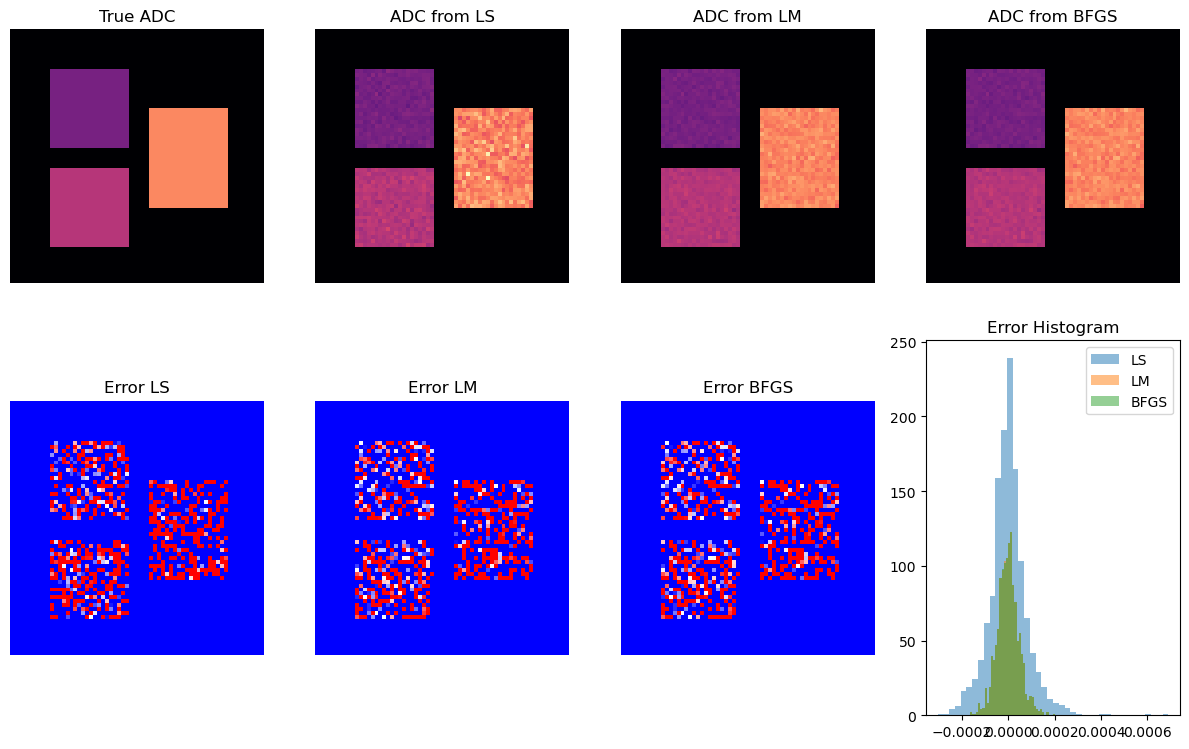

In [ ]:
import matplotlib.pyplot as plt

err_LS = (ADC_LS - ADC_true)
err_LM = (ADC_LM - ADC_true)
err_BFGS = (ADC_BFGS - ADC_true)

rmse_LS = np.sqrt(np.mean(err_LS[mask]**2))
rmse_LM = np.sqrt(np.mean(err_LM[mask]**2))
rmse_BFGS = np.sqrt(np.mean(err_BFGS[mask]**2))

print(f"RMSE LS: {rmse_LS:.6f}")
print(f"RMSE LM: {rmse_LM:.10f}")
print(f"RMSE BFGS: {rmse_BFGS:.10f}")

vmin, vmax = 0, 0.002  # ms

plt.figure(figsize=(12, 8))

plt.subplot(2, 4, 1)
plt.imshow(ADC_true, cmap="magma", vmin=vmin, vmax=vmax)
plt.title("True ADC")
plt.axis("off")

plt.subplot(2, 4, 2)
plt.imshow(ADC_LS, cmap="magma", vmin=vmin, vmax=vmax)
plt.title("ADC from LS")
plt.axis("off")

plt.subplot(2, 4, 3)
plt.imshow(ADC_LM, cmap="magma", vmin=vmin, vmax=vmax)
plt.title("ADC from LM")
plt.axis("off")

plt.subplot(2, 4, 4)
plt.imshow(ADC_BFGS, cmap="magma", vmin=vmin, vmax=vmax)
plt.title("ADC from BFGS")
plt.axis("off")

plt.subplot(2, 4, 5)
plt.imshow(err_LS, cmap="bwr", vmin=vmin/100, vmax=vmax/100)
plt.title("Error LS")
plt.axis("off")

plt.subplot(2, 4, 6)
plt.imshow(err_LM, cmap="bwr", vmin=vmin/100, vmax=vmax/100)
plt.title("Error LM")
plt.axis("off")

plt.subplot(2, 4, 7)
plt.imshow(err_BFGS, cmap="bwr", vmin=vmin/100, vmax=vmax/100)
plt.title("Error BFGS")
plt.axis("off")

plt.subplot(2, 4, 8)
plt.hist(err_LS[mask].ravel(), bins=40, alpha=0.5, label="LS")
plt.hist(err_LM[mask].ravel(), bins=40, alpha=0.5, label="LM")
plt.hist(err_BFGS[mask].ravel(), bins=40, alpha=0.5, label="BFGS")
plt.legend()
plt.title("Error Histogram")

plt.tight_layout()
plt.show()


Fra RMSE og plots kan vi se at alle tre optimerings algoritmer klarer sig ret godt.

### Del 2

Vi undersøger om vi kan benytte optimering (LM og TRF) til at beskrive logistisk vækst af en tumor (V).

Denne er beskrevet ud fra variablene: 

K: Carrying capacity

r: Growth rate

𝑨: Initial condition parameter

$$
V(t) = \frac{K}{1 + A e^{-r t}}
$$

#### 2a) Artificial data generation

In [ ]:
import numpy as np

days = np.linspace(0, 40, 20)
K, r, A = 1200, 0.12, 10
V = K / (1 + A*np.exp(-r*days)) + np.random.normal(0, 20, days.shape)

##### Define Logistic model

In [ ]:
def logistic(t, K, r, A):
    return K / (1 + A * np.exp(-r * t))

##### Levenberg-Marquardt (LM)

True values:    K=1200.00. r=0.12. A=10.00
LM fit:         K=1175.35. r=0.12. A=9.53


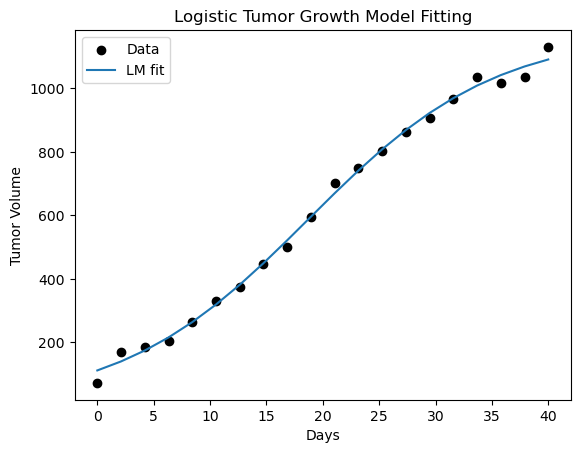

In [ ]:
params_lm, _ = curve_fit(
    logistic,
    days,
    V,
    #p0 = [0,0,0],
    p0=[500, 1, 1],
    method='lm'  # no bounds allowed
)

V_lm = logistic(days, *params_lm)

K_lm, r_lm, A_lm = params_lm
print(f"True values:    K={K:.2f}. r={r:.2f}. A={A:.2f}")
print(f"LM fit:         K={K_lm:.2f}. r={r_lm:.2f}. A={A_lm:.2f}")

plt.scatter(days, V, label="Data", color="black")
plt.plot(days, V_lm, label="LM fit")
plt.xlabel("Days")
plt.ylabel("Tumor Volume")
plt.legend()
plt.title("Logistic Tumor Growth Model Fitting")
plt.show()

Med de valgte startgæt kommer vores fit meget tæt på de sande værdier.

Ud fra vores viden bryder LM i dette tilfælde ikke med nogen fysiologiske grænser (negative værdier af K, r og A).

##### TRF algoritme

True values:    K=1200.00. r=0.12. A=10.00
trf fit:         K=1194.82. r=0.12. A=9.97


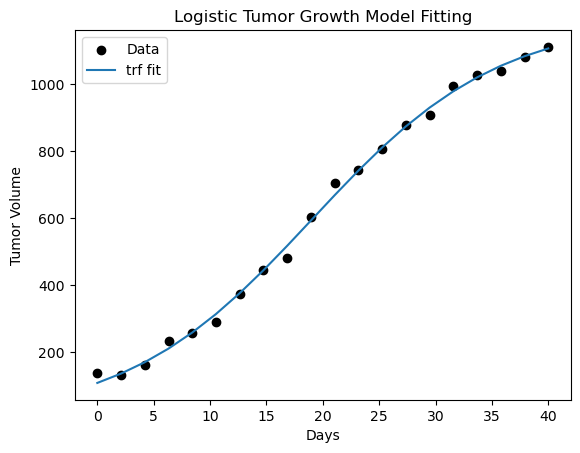

In [ ]:
params_trf, _ = curve_fit(
    logistic,
    days,
    V,
    #p0 = [0,0,0],
    p0=[500, 1, 1],
    method='trf',
    bounds=([0, 0, 0], [5000, 1, 100])  # bounds
)

V_trf = logistic(days, *params_trf)

K_trf, r_trf, A_trf = params_trf

print(f"True values:    K={K:.2f}. r={r:.2f}. A={A:.2f}")
print(f"trf fit:         K={K_trf:.2f}. r={r_trf:.2f}. A={A_trf:.2f}")

plt.scatter(days, V, label="Data", color="black")
plt.plot(days, V_trf, label="trf fit")
plt.xlabel("Days")
plt.ylabel("Tumor Volume")
plt.legend()
plt.title("Logistic Tumor Growth Model Fitting")
plt.show()

Fittet er identisk med det vi så hos LM algoritmen.

Vi tænker at så længe startgættet er nogenlunde godt og at grænseværdierne sættes realistisk, så burde algoritmen være stabil.